In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image 

In [3]:
DATASET_PATH = Path("../data/raw/PlantVillage/color")

print("Dataset Path:")
print(DATASET_PATH.resolve())

Dataset Path:
C:\Users\SAVINDU\Desktop\Projects\Smart-Agri-Crop-Disease-Detection-API\Smart-Agri-Crop-Disease-Detection-API\Smart-Agri-Crop-Disease-Detection-API\data\raw\PlantVillage\color


In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found : {DATASET_PATH.resolve()}"
    )

print("Dataset found successfully!")

Dataset found successfully!


In [5]:
class_directories = sorted(
    [
        directory 
        for directory in DATASET_PATH.iterdir()
        if directory.is_dir()

    ]
)

print(f"Number if classes : {len(class_directories)}")

print("\nClasses")
for index, directory in enumerate(class_directories, start = 1):
    print(f"{index:02d}. {directory.name}")

Number if classes : 38

Classes
01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___healthy
07. Cherry_(including_sour)___Powdery_mildew
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___healthy
11. Corn_(maize)___Northern_Leaf_Blight
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___healthy
15. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___healthy
23. Potato___Late_blight
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___healthy
28. Strawberry___Leaf_scorch
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___healthy
32. Tomato___Late_blight
33. Tomato___Leaf_Mold
34. Tomato___Se

In [6]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

class_counts = {}

for class_directory in class_directories:

    images = [
        file
        for file in class_directory.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_counts[class_directory.name] = len(images)

class_counts

{'Apple___Apple_scab': 630,
 'Apple___Black_rot': 621,
 'Apple___Cedar_apple_rust': 275,
 'Apple___healthy': 1645,
 'Blueberry___healthy': 1502,
 'Cherry_(including_sour)___healthy': 854,
 'Cherry_(including_sour)___Powdery_mildew': 1052,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 513,
 'Corn_(maize)___Common_rust_': 1192,
 'Corn_(maize)___healthy': 1162,
 'Corn_(maize)___Northern_Leaf_Blight': 985,
 'Grape___Black_rot': 1180,
 'Grape___Esca_(Black_Measles)': 1383,
 'Grape___healthy': 423,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1076,
 'Orange___Haunglongbing_(Citrus_greening)': 5507,
 'Peach___Bacterial_spot': 2297,
 'Peach___healthy': 360,
 'Pepper,_bell___Bacterial_spot': 997,
 'Pepper,_bell___healthy': 1478,
 'Potato___Early_blight': 1000,
 'Potato___healthy': 152,
 'Potato___Late_blight': 1000,
 'Raspberry___healthy': 371,
 'Soybean___healthy': 5090,
 'Squash___Powdery_mildew': 1835,
 'Strawberry___healthy': 456,
 'Strawberry___Leaf_scorch': 1109,
 'Tomato___Bac

In [9]:
class_distribution = pd.DataFrame(
    {
        "class": list(class_counts.keys()),
        "image_count": list(class_counts.values())
    }
)

class_distribution

,class,image_count
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___healthy,854
6,Cherry_(including_sour)___Powdery_mildew,1052
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___healthy,1162


In [10]:
total_images = class_distribution["image_count"].sum()

print(f"Total images: {total_images:,}")

Total images: 54,305


In [13]:
smallest_class = class_distribution.loc[
    class_distribution["image_count"].idxmin()
]

largest_class = class_distribution.loc[
    class_distribution["image_count"].idxmax()
]

print("Smallest class:")
print(smallest_class)

print("\nLargest class:")
print(largest_class)

Smallest class:
class          Potato___healthy
image_count                 152
Name: 21, dtype: object

Largest class:
class          Orange___Haunglongbing_(Citrus_greening)
image_count                                        5507
Name: 15, dtype: object


In [14]:
class_distribution_sorted = class_distribution.sort_values(
    by="image_count",
    ascending = False 
)

class_distribution_sorted 

,class,image_count
15,Orange___Haunglongbing_(Citrus_greening),5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
31,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
33,Tomato___Septoria_leaf_spot,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


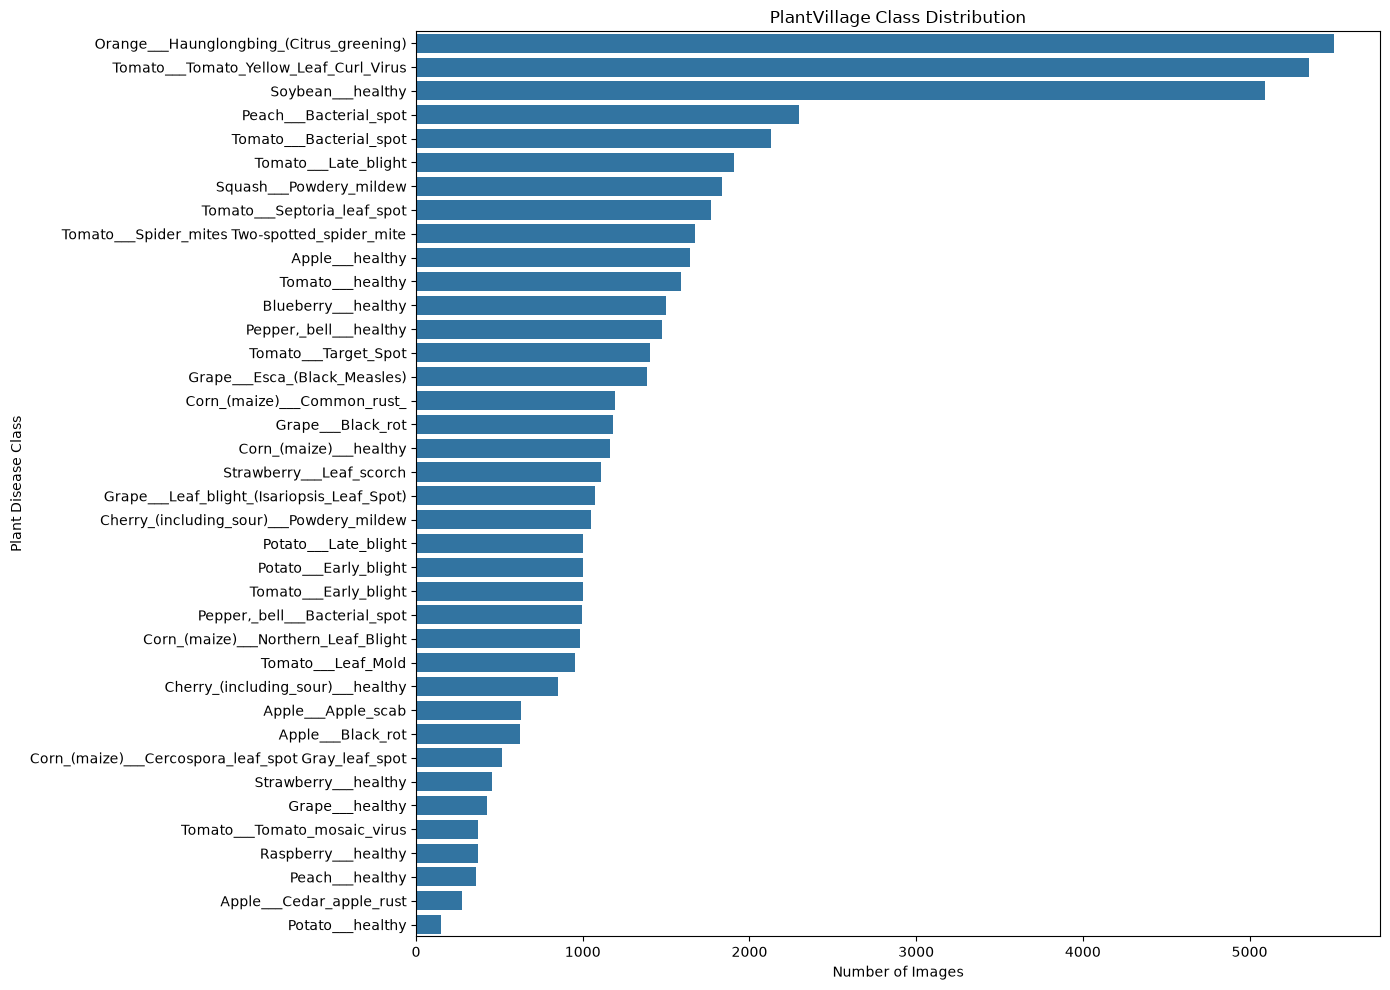

In [16]:
plt.figure(figsize=(14, 10))

sns.barplot(
    data=class_distribution_sorted,
    x="image_count",
    y="class"
)

plt.title("PlantVillage Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Plant Disease Class")

plt.tight_layout()

plt.savefig(
    "../reports/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

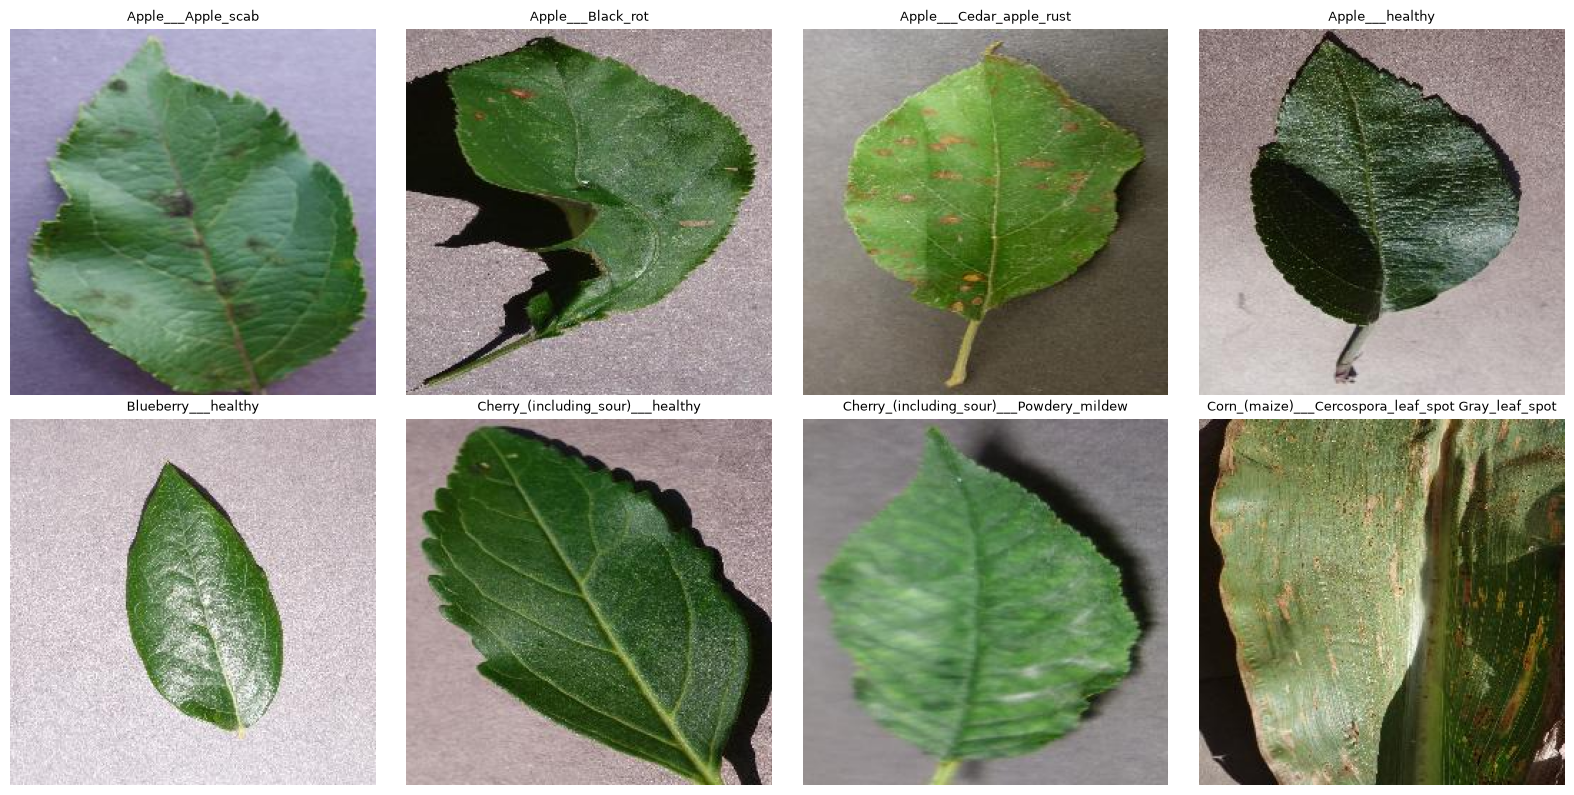

In [18]:
fig, axes = plt.subplots(
    2,
    4,
    figsize = (16, 8)
)

for ax, class_directory in zip(
    axes.flatten(),
    class_directories[:8]
):

    image_files = [
        file
        for file in class_directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if not image_files:
        continue

    image_path = image_files[0]

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_directory.name, fontsize = 9)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [19]:
import random


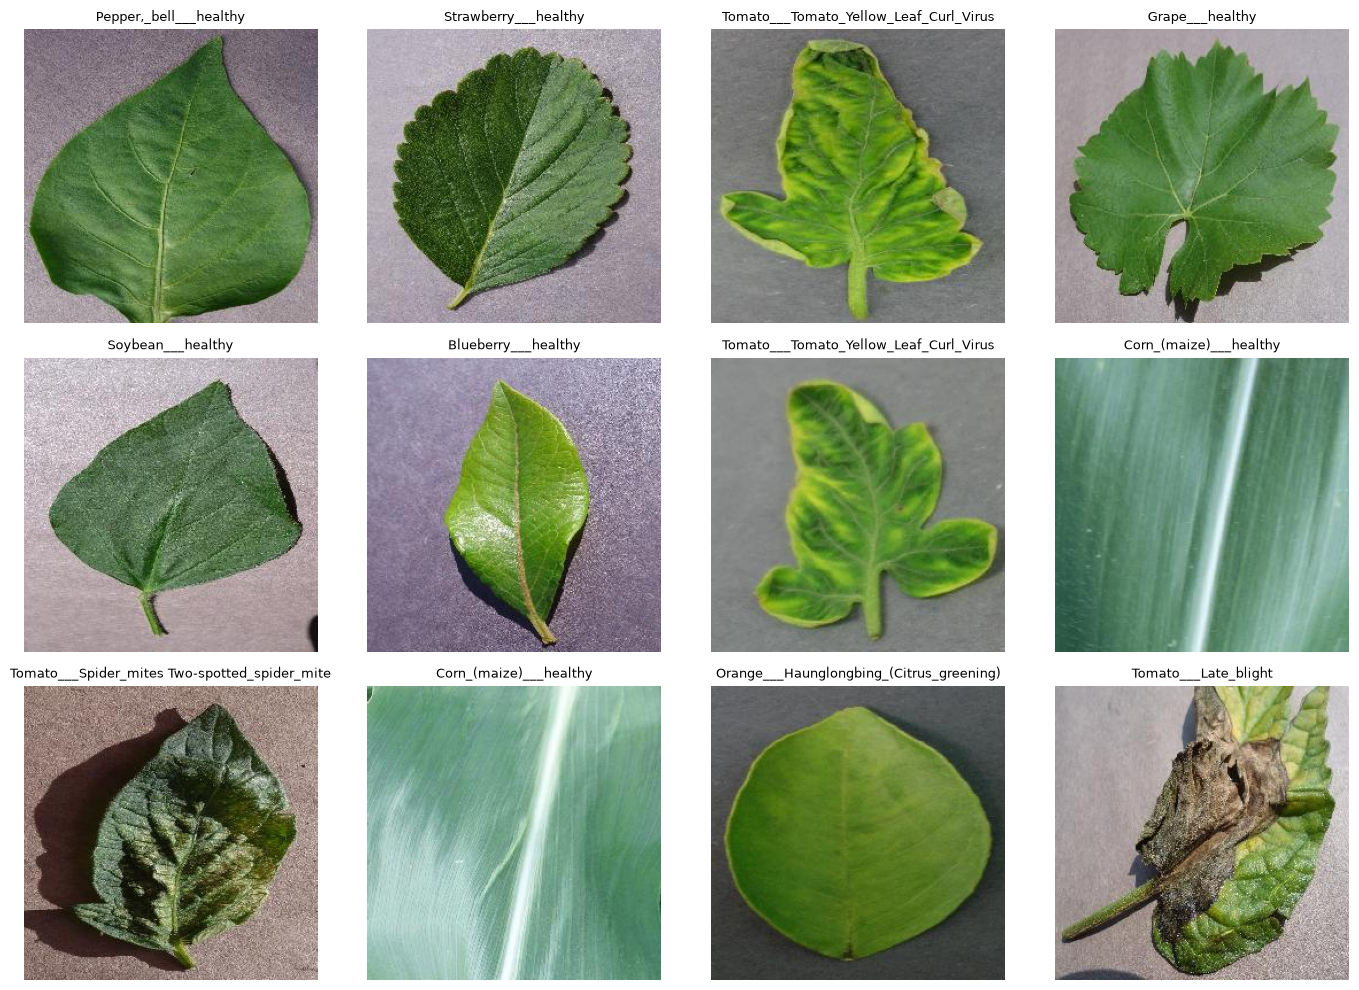

In [21]:
fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax in axes.flatten():

    class_directory = random.choice(class_directories)

    image_files = [
        file
        for file in class_directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = random.choice(image_files)

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(class_directory.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
image_sizes = []

for class_directory in class_directories:

    image_files = [
        file
        for file in class_directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in image_files[:20]:

        try:

            with Image.open(image_path) as image:

                width, height = image.size

                image_sizes.append(
                    {
                        "class": class_directory.name,
                        "width": width,
                        "height": height
                    }
                )

        except Exception:
            pass

sizes_df = pd.DataFrame(image_sizes)

sizes_df.head()

,class,width,height
0,Apple___Apple_scab,256,256
1,Apple___Apple_scab,256,256
2,Apple___Apple_scab,256,256
3,Apple___Apple_scab,256,256
4,Apple___Apple_scab,256,256


In [23]:
size_counts = (
    sizes_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

size_counts.head(20)

,width,height,count
0,256,256,760


In [24]:
color_modes = Counter()

sample_count = 0

for class_directory in class_directories:

    image_files = [
        file
        for file in class_directory.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for image_path in image_files[:10]:

        try:

            with Image.open(image_path) as image:

                color_modes[image.mode] += 1
                sample_count += 1

        except Exception:
            pass

print("Color modes found:")

for mode, count in color_modes.items():
    print(f"{mode}: {count}")

Color modes found:
RGB: 380


In [25]:
sample_class = class_directories[0]

sample_image_path = next(
    file
    for file in sample_class.iterdir()
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
)

sample_image = Image.open(sample_image_path).convert("RGB")

image_array = np.array(sample_image)

print("Image shape:")
print(image_array.shape)

print("\nMinimum pixel value:")
print(image_array.min())

print("\nMaximum pixel value:")
print(image_array.max())

Image shape:
(256, 256, 3)

Minimum pixel value:
0

Maximum pixel value:
226


In [27]:
max_images = class_distribution["image_count"].max()
min_images = class_distribution["image_count"].min()

imbalance_ratio = max_images / min_images

print(f"Maximum images in a class: {max_images}")
print(f"Minimum images in a class: {min_images}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Maximum images in a class: 5507
Minimum images in a class: 152
Imbalance ratio: 36.23


In [28]:
print("=" * 60)
print("SMART AGRI - DATASET SUMMARY")
print("=" * 60)

print(f"Dataset type       : PlantVillage")
print(f"Dataset version    : Color images")
print(f"Number of classes  : {len(class_directories)}")
print(f"Total images       : {total_images:,}")
print(f"Smallest class     : {smallest_class['class']}")
print(f"Smallest count     : {smallest_class['image_count']}")
print(f"Largest class      : {largest_class['class']}")
print(f"Largest count      : {largest_class['image_count']}")
print(f"Imbalance ratio    : {imbalance_ratio:.2f}")

print("=" * 60)

SMART AGRI - DATASET SUMMARY
Dataset type       : PlantVillage
Dataset version    : Color images
Number of classes  : 38
Total images       : 54,305
Smallest class     : Potato___healthy
Smallest count     : 152
Largest class      : Orange___Haunglongbing_(Citrus_greening)
Largest count      : 5507
Imbalance ratio    : 36.23


In [29]:
class_distribution.to_csv(
    "../reports/class_distribution.csv",
    index=False
)

print("Class distribution saved.")

Class distribution saved.
